## Trabajo Computacional 1 - Aceleradores y detectores de partículas 


***Grupo:*** Catalina Fuentes (202220750), Daniela León (202211020), David Cantini (codigo)

***Fundamento del problema:*** 
Un protón de 100 MeV penetra en Silicio y pierde energía continuamente por ionización (fórmula de Bethe-Bloch). El alcance R es la profundidad total hasta que el protón se detiene.

### Parte A — dE/dx en función de E

La gráfica de la página 17 de Marion & Young muestra el poder de frenado (stopping power) dE/dx vs la energía E de protones en Silicio en escala logarítmica. El eje Y está en keV/mm y el eje X en MeV. Esta cantidad describe cuánta energía pierde el protón por milímetro recorrido.

 La curva sigue aproximadamente una ley de potencia, lo que en escala logarítmica se traduce en una línea casi recta. Por eso, ajustar un polinomio de grado 2 en log(E) vs log(dE/dx) es una buena aproximación: equivale a ajustar una parábola sobre la curva logarítmica, capturando tanto la tendencia general como la curvatura del pico de Bragg. Es importante recordar la fórmula de Bethe-Bloch relativista, que es la expresión teórica exacta para la pérdida de energía de partículas cargadas pesadas en materia:

$$
-\frac{dE}{dx} = K z^2 \frac{Z}{A} \frac{1}{\beta^2}
\left[
\frac{1}{2} \ln\left(\frac{2 m_e c^2 \beta^2 \gamma^2 W_{\text{max}}}{I^2}\right)
- \beta^2
\right] \cdot \rho
$$

donde I = 173 eV es la energía de excitación media del Silicio, Z=14, A=28, ρ=2.336 g/cm³.

In [65]:
import numpy as np
import matplotlib.pyplot as plt
# PARTE a) — TABLA E vs dE/dx y AJUSTE POLINOMIAL G

# QUÉ SE HACE:
#   Se construye una tabla de varios puntos (E, dE/dx) leyendo la curva
#   de PROTONS de la gráfica pág.17 de Marion & Young.
#   Luego se ajusta un polinomio de grado 3 en escala logarítmica para
#   obtener dE/dx(E) para cualquier valor de E.

# POR QUÉ SE HACE:
#   La integración numérica del paso b) requiere evaluar dE/dx a
#   energías arbitrarias entre 0 y 100 MeV. El ajuste polinomial
#   en escala logarítmica captura bien la forma de la curva (casi lineal en
#   esa escala) con muy pocos coeficientes.

# SIGNIFICADO FÍSICO:
#   dE/dx es el "poder de frenado" (stopping power): la energía
#   depositada por el protón por unidad de longitud recorrida.
#   A energías altas el protón deposita menos energía, mientras
#   que a energías bajas la pérdida aumenta (pico de Bragg).



# PASO 1: TABLA DE PUNTOS E VS dE/dx (LEÍDOS DE LA GRÁFICA)

E_tabla = np.array([0.10, 0.20, 0.30, 0.50, 0.70,
                    1.00, 1.50, 2.00, 3.00, 5.00, 7.00,
                    10.0, 15.0, 20.0, 30.0, 50.0, 70.0, 100., 150.]) 

dEdx_keV_mm = np.array([105.0, 88.0, 78.0, 66.0, 56.0,
                        45.0, 36.0, 27.0, 21.5, 14.5, 10.5,
                        8.5, 6.6, 5.0, 4.0, 2.8, 2.2, 1.6, 1.0])

# Los valores tienen una incertidumbre estimada del orden del 5–10%
# debido a la lectura manual en escala logarítmica.

# Imprimir la tabla completa
print("=" * 55)
print("TABLA a) — Puntos leídos de la gráfica pág.17")
print("           Protones en Silicio (Marion & Young)")
print("=" * 55)
print(f"{'E (MeV)':>10} | {'dE/dx (keV/mm)':>16}")
print("-" * 35)
for e, dk in zip(E_tabla, dEdx_keV_mm):
    print(f"{e:>10.2f} | {dk:>16.2f}")



TABLA a) — Puntos leídos de la gráfica pág.17
           Protones en Silicio (Marion & Young)
   E (MeV) |   dE/dx (keV/mm)
-----------------------------------
      0.10 |           105.00
      0.20 |            88.00
      0.30 |            78.00
      0.50 |            66.00
      0.70 |            56.00
      1.00 |            45.00
      1.50 |            36.00
      2.00 |            27.00
      3.00 |            21.50
      5.00 |            14.50
      7.00 |            10.50
     10.00 |             8.50
     15.00 |             6.60
     20.00 |             5.00
     30.00 |             4.00
     50.00 |             2.80
     70.00 |             2.20
    100.00 |             1.60
    150.00 |             1.00


In [66]:


# PASO 2: Ajuste polinomial grado 3 en escala logarítmica

log_E    = np.log10(E_tabla)
log_dEdx = np.log10(dEdx_keV_mm)

coeff2 = np.polyfit(log_E, log_dEdx, 3)

print(f"\nCoeficientes del polinomio grado 3 (log-log):")
print(f"  a3 = {coeff2[0]:.5f}")
print(f"  a2 = {coeff2[1]:.5f}")
print(f"  a1 = {coeff2[2]:.5f}")
print(f"  a0 = {coeff2[3]:.5f}")
print(f"\nFórmula: log10(dE/dx [keV/mm]) = "
      f"{coeff2[0]:.5f}·[log10(E)]³ "
      f"+ {coeff2[1]:.5f}·[log10(E)]² "
      f"+ {coeff2[2]:.5f}·log10(E) "
      f"+ {coeff2[3]:.5f}")


def dEdx_grafica(E_MeV):
    E_s   = np.maximum(np.asarray(E_MeV, float), 0.05) 
    log_E_input = np.log10(E_s)
    log_dEdx_output = np.polyval(coeff2, log_E_input)
    return 10**log_dEdx_output





Coeficientes del polinomio grado 3 (log-log):
  a3 = 0.03674
  a2 = -0.14902
  a1 = -0.57626
  a0 = 1.63920

Fórmula: log10(dE/dx [keV/mm]) = 0.03674·[log10(E)]³ + -0.14902·[log10(E)]² + -0.57626·log10(E) + 1.63920


In [67]:
# PASO 3: Verificar la calidad del ajuste

print(f"\n{'E (MeV)':>8} | {'Gráfica (keV/mm)':>18} | "
      f"{'Poly-3 (keV/mm)':>18} | {'Error%':>8}")
print("-" * 60)
for e, d in zip(E_tabla, dEdx_keV_mm):
    p   = dEdx_grafica(e)
    err = 100 * (p - d) / d
    print(f"{e:>8.2f} | {d:>18.2f} | {p:>18.2f} | {err:>8.1f}%")


 E (MeV) |   Gráfica (keV/mm) |    Poly-3 (keV/mm) |   Error%
------------------------------------------------------------
    0.10 |             105.00 |             107.08 |      2.0%
    0.20 |              88.00 |              90.50 |      2.8%
    0.30 |              78.00 |              78.44 |      0.6%
    0.50 |              66.00 |              62.83 |     -4.8%
    0.70 |              56.00 |              53.06 |     -5.3%
    1.00 |              45.00 |              43.57 |     -3.2%
    1.50 |              36.00 |              34.14 |     -5.2%
    2.00 |              27.00 |              28.39 |      5.2%
    3.00 |              21.50 |              21.59 |      0.4%
    5.00 |              14.50 |              15.00 |      3.5%
    7.00 |              10.50 |              11.69 |     11.4%
   10.00 |               8.50 |               8.93 |      5.0%
   15.00 |               6.60 |               6.53 |     -1.0%
   20.00 |               5.00 |               5.23 |     

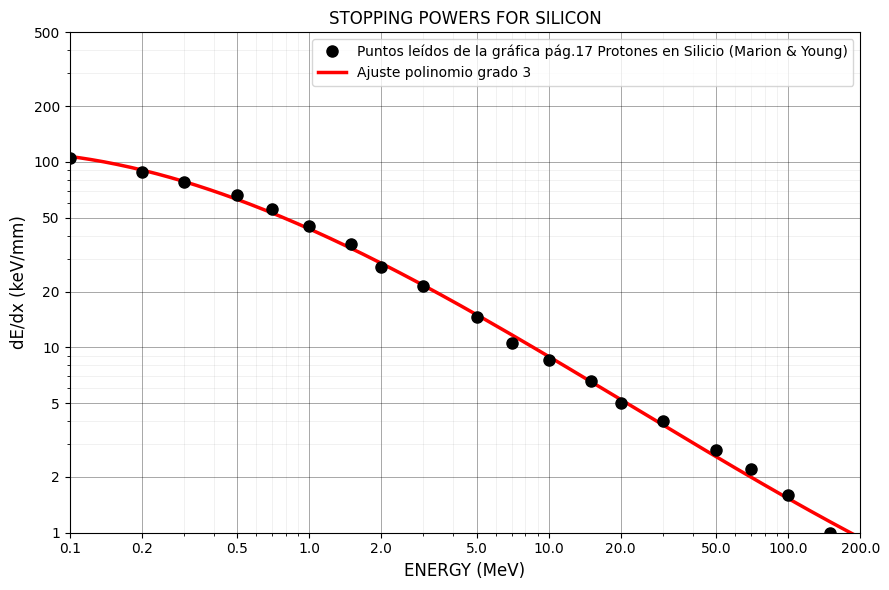

In [ ]:
# PASO 4: Gráfica

E_plot     = np.logspace(np.log10(0.1), np.log10(200), 300)
dEdx_ajuste = dEdx_grafica(E_plot)

fig, ax = plt.subplots(figsize=(9, 6))

ax.set_xscale('log')
ax.set_yscale('log')

x_ticks = [0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100, 200]
y_ticks = [1, 2, 5, 10, 20, 50, 100, 200, 500]

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())

ax.grid(which='major', color='black', alpha=0.4, linewidth=0.6)
ax.grid(which='minor', color='gray', alpha=0.2, linewidth=0.4)

ax.minorticks_on()

ax.plot(E_tabla, dEdx_keV_mm, 'ko', ms=8, zorder=5,
        label='Puntos leídos de la gráfica pág.17 Protones en Silicio (Marion & Young)')
ax.plot(E_plot, dEdx_ajuste, 'r-', lw=2.5,
        label='Ajuste polinomio grado 3')

ax.set_xlim(0.1, 200)
ax.set_ylim(1, 500)

ax.set_xlabel('ENERGY (MeV)', fontsize=12)
ax.set_ylabel('dE/dx (keV/mm)', fontsize=12)

ax.set_title('STOPPING POWERS FOR SILICON', fontsize=12)

ax.legend()
plt.tight_layout()
plt.show()